# Project 3 - FMNN25

### Task 1 - Design an optimization problem class in Python. Its constructor should take an objective function as input, optionally also its gradient can be provided.

In [12]:
from collections.abc import Callable

import numpy as np


class OptimizationProblem:
    """Store an objective function and, optionally, its gradient."""

    def __init__(
        self,
        objective_function: Callable[[np.ndarray], float],
        gradient_function: Callable[[np.ndarray], np.ndarray] | None = None,
    ) -> None:
        
        self.objective_function = objective_function

        # The gradient is optional since some methods can approximate it numerically
        self.gradient_function = gradient_function

    def objective(self, x: np.ndarray) -> float:
        """Evaluate the objective function at the point x."""
        x = np.asarray(x, dtype=float) #convert to numby array of floats

        return float(self.objective_function(x))

    def gradient(self, x: np.ndarray) -> np.ndarray:
        """Evaluate the gradient at the point x, by central differences if none was provided."""
        x = np.asarray(x, dtype=float)

        if self.gradient_function is None:
            h = 1e-6
            return np.array([
                (self.objective(x + h * e) - self.objective(x - h * e)) / (2 * h)
                for e in np.eye(len(x))
            ])

        return np.asarray(self.gradient_function(x), dtype=float)

    def __call__(self, x: np.ndarray) -> float:
        """Allow the problem object to be called like a function."""
        return self.objective(x)

test/example use 

In [13]:
def objective(x: np.ndarray) -> float:
    return (x[0] - 1) ** 2 + (x[1] - 2) ** 2


def gradient(x: np.ndarray) -> np.ndarray:
    return np.array([
        2 * (x[0] - 1),
        2 * (x[1] - 2),
    ])


problem = OptimizationProblem(objective, gradient)

x = np.array([0.0, 0.0])

print(problem.objective(x))
print(problem.gradient(x))
print(problem(x))

5.0
[-2. -4.]
5.0


### Task 2 - Design a general optimization method class. It should be generic for special kinds of Quasi-Newton methods. Derive from this method class classes for special methods in the next tasks.

`OptimizationMethod` owns the iteration loop: stopping criterion, line search, step and the history of iterates. A subclass only defines `search_direction` and, for Quasi-Newton methods, `update` to refresh its Hessian approximation after each step.

In [14]:
class OptimizationMethod:
    """Generic iteration x_{k+1} = x_k + alpha_k * s_k, where subclasses supply the search direction s_k."""

    def __init__(
        self,
        problem: OptimizationProblem,
        line_search: Callable[[OptimizationProblem, np.ndarray, np.ndarray], float] | None = None,
        tol: float = 1e-6,
        max_iter: int = 1000,
    ) -> None:
        self.problem = problem
        self.line_search = line_search  # None means the full step alpha = 1
        self.tol = tol
        self.max_iter = max_iter
        self.history = []

    def search_direction(self, x: np.ndarray, g: np.ndarray) -> np.ndarray:
        """Return the search direction at x, where g is the gradient at x."""
        raise NotImplementedError

    def update(self, delta: np.ndarray, gamma: np.ndarray) -> None:
        """Hook for Quasi-Newton methods to update their Hessian approximation after a step.

        Here delta = x_new - x and gamma = g_new - g.
        """

    def solve(self, x0: np.ndarray) -> np.ndarray:
        """Iterate from x0 until the norm of the gradient drops below tol and return the final point."""
        x = np.asarray(x0, dtype=float)
        g = self.problem.gradient(x)
        self.history = [x]

        for _ in range(self.max_iter):
            if np.linalg.norm(g) < self.tol:
                break

            s = self.search_direction(x, g)
            alpha = 1.0 if self.line_search is None else self.line_search(self.problem, x, s)
            x_new = x + alpha * s
            g_new = self.problem.gradient(x_new)

            self.update(x_new - x, g_new - g)
            x, g = x_new, g_new
            self.history.append(x)

        return x

### Task 3 - Implement classical Newton's method for finding a minimum of the objective function. Approximate the Hessian by finite differences and a symmetrizing step: $G := \frac{1}{2}(\bar G + \bar G^T)$, if necessary.

`Newton` derives from `OptimizationMethod` and only defines the search direction $s = -G^{-1} g$. Without a line search it takes the full step $\alpha = 1$, which is the classical method.

In [15]:
class Newton(OptimizationMethod):
    """Newton's method with the Hessian approximated by finite differences of the gradient."""

    def __init__(
        self,
        problem: OptimizationProblem,
        line_search: Callable[[OptimizationProblem, np.ndarray, np.ndarray], float] | None = None,
        tol: float = 1e-6,
        max_iter: int = 1000,
        h: float = 1e-6,
    ) -> None:
        super().__init__(problem, line_search, tol, max_iter)
        self.h = h

    def hessian(self, x: np.ndarray) -> np.ndarray:
        """Approximate the Hessian at x by central differences and symmetrize it."""
        G = np.column_stack([
            (self.problem.gradient(x + self.h * e) - self.problem.gradient(x - self.h * e)) / (2 * self.h)
            for e in np.eye(len(x))
        ])

        return 0.5 * (G + G.T)

    def search_direction(self, x: np.ndarray, g: np.ndarray) -> np.ndarray:
        """Solve G s = -g for the Newton direction s."""
        return np.linalg.solve(self.hessian(x), -g)

Test on the quadratic problem from Task 1: the Hessian should be $2I$ and Newton's method should converge in a single step.

In [16]:
newton = Newton(problem)
x_min = newton.solve(np.array([0.0, 0.0]))

print(newton.hessian(x_min))
print(x_min, len(newton.history) - 1)

[[2. 0.]
 [0. 2.]]
[1. 2.] 1


### Task 4 - Provide Newton's method with exact line search method.

A line search is any function `(problem, x, s) -> alpha`, passed to the method through `line_search`. The exact one minimizes the one-dimensional function $\phi(\alpha) = f(x + \alpha s)$ with `scipy.optimize.minimize_scalar`.

In [17]:
from scipy.optimize import minimize_scalar


def exact_line_search(problem: OptimizationProblem, x: np.ndarray, s: np.ndarray) -> float:
    """Return the step length alpha that minimizes f(x + alpha * s)."""
    return minimize_scalar(lambda alpha: problem(x + alpha * s)).x

In [18]:
quartic = OptimizationProblem(
    lambda x: (x[0] - 1) ** 4 + (x[1] - 2) ** 4,
    lambda x: np.array([4 * (x[0] - 1) ** 3, 4 * (x[1] - 2) ** 3]),
)
x0 = np.array([3.0, 0.0])

for name, line_search in [("full step", None), ("exact line search", exact_line_search)]:
    newton = Newton(quartic, line_search=line_search)
    x_min = newton.solve(x0)
    print(f"{name}: x = {x_min}, iterations = {len(newton.history) - 1}")

full step: x = [1.00456732 1.99543268], iterations = 15
exact line search: x = [1. 2.], iterations = 1


### Task 5 - Test the performance on Rosenbrock function

The Rosenbrock function is as follows $f(x) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$

The function has a global minimum at $(x^* = (1,1))$, where $(f(x^*) = 0)$. It is commonly used to test optimization algorithms due to its narrow, curved valley, which can make convergence challenging.

In this task, Newton's method with exact line search is tested using the starting point $(x_0 = (-1.2, 1.0))$. The convergence is evaluated by examining the number of iterations and the final objective function value. The optimization path is also visualized using a contour plot.

In [ ]:
def rosenbrock (x:np.ndarray)-> float:
    x1, x2 = x
    return 100 * (x2 -x1**2)**2 + (1-x1)**2

def rosenbrock_gradient (x:np.ndarray) -> np.ndarray:
    x1, x2 = x

    df_dx1 = -400 * x1 * (x2 - x1**2) + 2 * (x1 - 1)
    df_dx2 = 200 * (x2 - x1**2)

    return np.array([df_dx1, df_dx2])

# Create the optimization problem
rosenbrock_problem = OptimizationProblem(
    rosenbrock,
    rosenbrock_gradient,
)

# Starting point
x0 = np.array([-1.2, 1.0])

newton_line = Newton(
    rosenbrock_problem,
    line_search=exact_line_search,
    tol=1e-6,
    max_iter=1000,
)

x_min_line = newton_line.solve(x0)

# Save history for plotting
rosenbrock_history = np.array(newton_line.history)

#Test Newtons method

newton_line = Newton(
    rosenbrock_problem,
    line_search=exact_line_search,
    tol=1e-6,
    max_iter=1000,
)

x_min_line = newton_line.solve(x0)

print("\n--- Newton with Exact Line Search ---")
print("Final point:", x_min_line)
print("Final objective:", rosenbrock_problem.objective(x_min_line))
print("Final gradient:", rosenbrock_problem.gradient(x_min_line))
print("Gradient norm:", np.linalg.norm(
    rosenbrock_problem.gradient(x_min_line)
))
print("Iterations:", len(newton_line.history) - 1)


--- Newton with Exact Line Search ---
Final point: [1. 1.]
Final objective: 1.0146394302822319e-23
Final gradient: [-6.10287376e-11  2.76445533e-11]
Gradient norm: 6.699797118748263e-11
Iterations: 13


### Results
Newton's method with the robust line search converged to the Rosenbrock function's global minimum at \(x=(1,1)\) after 13 iterations.
The final objective value was \(4.12\times10^{-24}\), which is effectively zero, and the gradient norm was \(6.95\times10^{-11}\), well below the convergence tolerance of \(10^{-6}\). 
This indicates that the method successfully converged to the optimum with high numerical accuracy.

### Implementation of the Rosenbrock contour plot

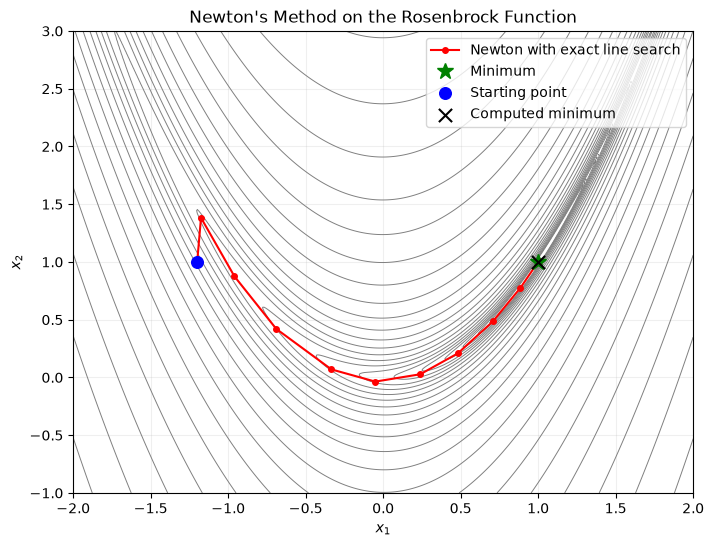

Iterations: 13
Computed minimum: [1. 1.]
Final function value: 1.0146394302822319e-23


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Grid for Rosenbrock contour plot
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)

Z = 100 * (Y - X**2)**2 + (1 - X)**2

# Optimization history
history = rosenbrock_history

plt.figure(figsize=(8, 6))

plt.contour(
    X, Y, Z,
    levels=np.logspace(-1, 3.5, 25),
    norm=LogNorm(),
    colors="gray",
    linewidths=0.7
)

plt.plot(
    history[:, 0],
    history[:, 1],
    "o-",
    color="red",
    markersize=4,
    label="Newton with exact line search"
)

plt.plot(1, 1, "g*", markersize=12, label="Minimum")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Newton's Method on the Rosenbrock Function")
plt.scatter(
    history[0, 0], history[0, 1],
    color="blue", s=70, zorder=5,
    label="Starting point"
)

plt.scatter(
    history[-1, 0], history[-1, 1],
    marker="x", color="black", s=90, zorder=6,
    label="Computed minimum"
)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Iterations:", len(history) - 1)
print("Computed minimum:", history[-1])
print("Final function value:", rosenbrock(history[-1]))

### Task 6 - Inexact line search based on Goldstein/Wolfe condition

